In [1]:
import os
# import gc
import asyncio
from typing import Type

from connector.monitor import Monitor
from connector.connector import BaseConnector
from connector.binance.binance_perp import BinancePerp
from connector.binance.binance_spot import BinanceSpot

print(f"PID: {os.getpid()}")
connector_type_list: list[Type[BaseConnector]] = [BinancePerp, BinanceSpot]
m = Monitor(connector_type_list=connector_type_list)
#gc.disable()
task = asyncio.create_task(m.run())


PID: 3193336


In [3]:
task.cancel()  # отправляем CancelledError в run()
await task 

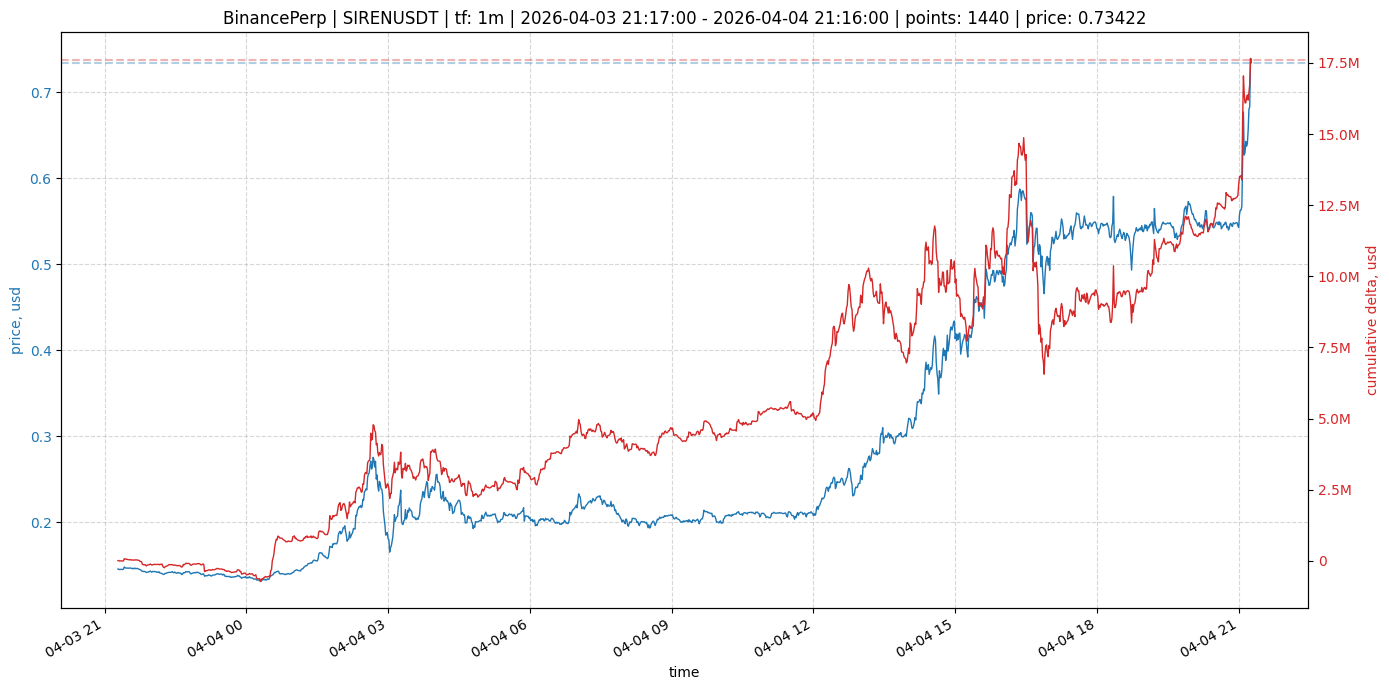

SIRENUSDT: буфер пуст


In [161]:
import importlib
import connector.visualization as visual
importlib.reload(visual)

symbol = "SIRENUSDT"
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinancePerp], "1m")
await asyncio.to_thread(visual.plot_price_and_cumulative_delta_notional, symbol, m.connectors[BinanceSpot], "1m")

In [56]:
import importlib
import connector.utils_io as utils_io
importlib.reload(utils_io)

await utils_io.save_all_trade_data(m.connectors)

In [ ]:
import pandas as pd
from typing import Any
rows: list[dict[str, Any]] = []
for symbol, trade_container in m.connectors[BinancePerp].trade_service.containers.items():
    idx = trade_container.public_trades_1m.idx
    wrapped = trade_container.public_trades_1m.wrapped
    size = trade_container.public_trades_1m.size
    price_close = trade_container.public_trades_1m.prices[idx]
    price_open = trade_container.public_trades_1m.prices[(idx + 1) % size if wrapped else 0]
    rows.append({"symbol": symbol, "price_open": price_open, "price_close": price_close, "delta": round((price_close/price_open-1)*100, 1)})

df = pd.DataFrame(rows)
df.sort_values("delta", ascending=False)


112


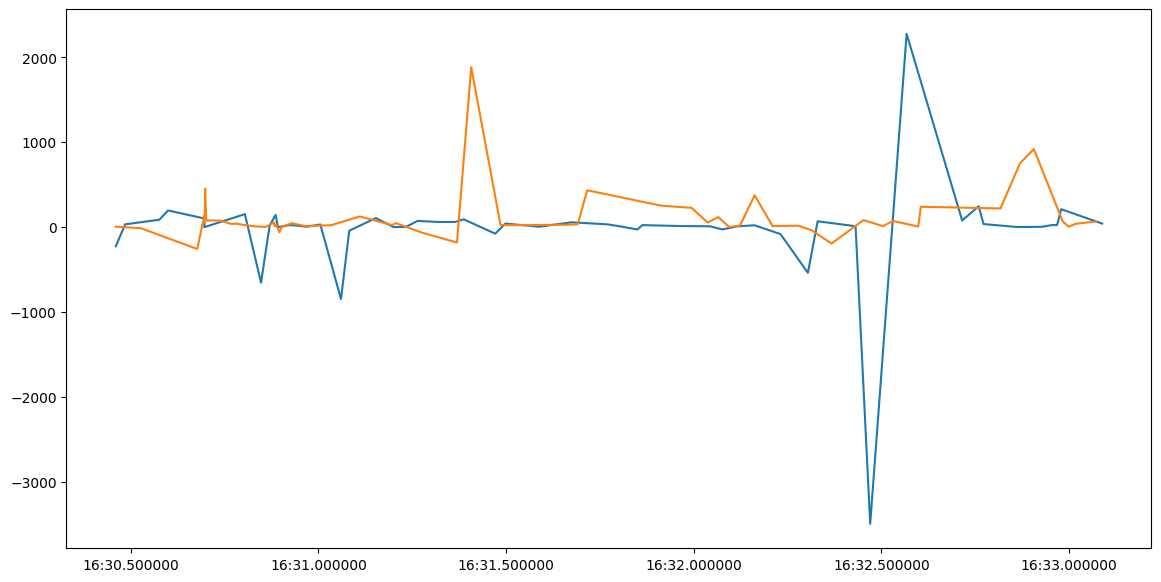

In [160]:
symbol = "SIRENUSDT"
group_trades: list[dict[str, Any]] = []
public_trades = m.connectors[BinancePerp].trade_service[symbol].public_trades
start = public_trades.idx + 1
end = len(public_trades)

price_open, price_close, amount = 0.0, 0.0, 0.0
for t, price, qty in zip(public_trades.timestamps[start: end], public_trades.prices[start: end], public_trades.volumes[start: end]):
    if amount * qty > 0:
        price_close = price
        amount += price * qty
    else:
        if price_close != 0.0 and price_close != price_open:
            group_trades.append({"t": pd.to_datetime(t, unit="ms"), "price_open": price_open, "price_close": price_close, "amount": amount, "v_dp": int(amount/(price_close-price_open)/100000)})
        price_open, price_close, amount = price, 0.0, qty

for t, price, qty in zip(public_trades.timestamps[: start], public_trades.prices[: start], public_trades.volumes[: start]):
    if amount * qty > 0:
        price_close = price
        amount += price * qty
    else:
        if price_close != 0.0 and price_close != price_open:
            group_trades.append({"t": pd.to_datetime(t, unit="ms"), "price_open": price_open, "price_close": price_close, "amount": amount, "v_dp": int(amount/(price_close-price_open)/100000)})
        price_open, price_close, amount = price, 0.0, qty
df = pd.DataFrame(group_trades)
print(len(df))
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
df2 = df[df.amount < 0]
plt.plot(df2.t, df2.v_dp)
df2 = df[df.amount > 0]
_=plt.plot(df2.t, df2.v_dp)

In [34]:
m.connectors[BinanceSpot].instrument_manager["BTCUSDT"]

Instrument(exchange_symbol='BTCUSDT', unified_symbol='BTCUSDT', min_price=None, max_price=None, price_step=None, min_qty=None, max_qty=None, qty_step=None)

In [11]:
m.connectors[BinancePerp].trade_service.containers.items()

dict_items([('APTUSDT', <connector.public_trade_service.TradesContainer object at 0x77e3c4183950>), ('1000CATUSDT', <connector.public_trade_service.TradesContainer object at 0x77e3c43e6dd0>), ('SOPHUSDT', <connector.public_trade_service.TradesContainer object at 0x77e3c415cfd0>), ('SAGAUSDT', <connector.public_trade_service.TradesContainer object at 0x77e3c4183750>), ('0GUSDT', <connector.public_trade_service.TradesContainer object at 0x77e3c4183a90>), ('DOLOUSDT', <connector.public_trade_service.TradesContainer object at 0x77e3c4180d90>), ('GIGGLEUSDT', <connector.public_trade_service.TradesContainer object at 0x77e393669110>), ('HUMAUSDT', <connector.public_trade_service.TradesContainer object at 0x77e393669150>), ('TIAUSDT', <connector.public_trade_service.TradesContainer object at 0x77e393669190>), ('SAHARAUSDT', <connector.public_trade_service.TradesContainer object at 0x77e3936691d0>), ('LAYERUSDT', <connector.public_trade_service.TradesContainer object at 0x77e393669210>), ('DEN

In [ ]:
perp_symbols = set(instrument.unified_symbol for instrument in m.connectors[BinancePerp].instrument_manager.values())
spot_symbols = set(instrument.unified_symbol for instrument in m.connectors[BinanceSpot].instrument_manager.values())
unified_symbols = perp_symbols & spot_symbols
len(perp_symbols), len(spot_symbols), len(unified_symbols)

(542, 439, 371)

In [ ]:
m.connectors[BinancePerp].orderbook_service["BTCUSDT"].message

''

In [ ]:
m.connectors[BinanceSpot].orderbook_service["BTCUSDT"].message

'{"u":91193085088,"s":"BTCUSDT","b":"67026.03000000","B":"2.42203000","a":"67026.04000000","A":"0.24394000"}'

In [ ]:
m.connectors[BinanceSpot].trade_service["BTCUSDT"].public_trades

68300.37

In [ ]:
m.connectors[BinanceSpot].trade_service["BTCUSDT"].public_trades_1s

In [4]:
min_delay = 0

In [ ]:
exchange_symbol = "BTCUSDT"
perp_ask_price: float = m.connectors[BinancePerp].orderbook_service[exchange_symbol].best_ask
perp_bid_price: float = m.connectors[BinancePerp].orderbook_service[exchange_symbol].best_bid
spot_bid_price: float = m.connectors[BinanceSpot].orderbook_service[exchange_symbol].best_bid
spot_ask_price: float = m.connectors[BinanceSpot].orderbook_service[exchange_symbol].best_ask
delay = int(time.time()*1000 - m.connectors[BinanceSpot].orderbook_service[exchange_symbol].transaction_ts_ms)
delay2 = int(time.time()*1000 - m.connectors[BinancePerp].trade_service[exchange_symbol][-1].transaction_ts_ms)
if min_delay>delay:
    min_delay=delay
perp_ask_price, perp_bid_price, spot_bid_price, spot_ask_price, delay-min_delay, delay2-min_delay, min_delay

(0, 0, 0, 0, 76, 65, -1063)

In [ ]:
m.connectors[BinancePerp].orderbook_service.text_data.qsize()

0